In [56]:
# ── Imports & Setup ──────────────────────────────────────────────────────
import importlib
import logging
from IPython.display import display, Image, HTML

# Force-reload to pick up code changes
import dpn_discovery.dpn_transform
importlib.reload(dpn_discovery.dpn_transform)
import dpn_discovery.pipeline
importlib.reload(dpn_discovery.pipeline)
import dpn_discovery.ilp_pipeline
importlib.reload(dpn_discovery.ilp_pipeline)

from dpn_discovery.models import Event, Trace, EventLog, MergeStrategy
from dpn_discovery.preprocessing import parse_event_log
from dpn_discovery.pipeline import run_pipeline, run_pipeline_full
from dpn_discovery.ilp_pipeline import run_ilp_pipeline, run_ilp_pipeline_full
from dpn_discovery.dpn_transform import dpn_to_pnml
from dpn_discovery.smt import get_solver, set_solver
from dpn_discovery.smt.yices2_solver import Yices2SMTSolver
from dpn_discovery.visualization import DPNVisualizer, VisualizerSettings

# Use Yices2 as the SMT backend
set_solver(Yices2SMTSolver())
smt = get_solver()

# Logging: show pipeline steps
logging.basicConfig(level=logging.INFO, format="%(levelname)-8s %(message)s", force=True)

# Visualization settings (SVG for inline display)
viz_settings = VisualizerSettings(output_format="svg", rankdir="LR")
viz = DPNVisualizer(viz_settings)

In [ ]:
def show_results_ilp(name: str, log: EventLog, alpha: float = 1.0):
    print(f"\n{'='*70}")
    print(f"{'='*70}")
    print(f"  Traces: {len(log.traces)}  |  Activities: {log.activities}  |  Variables: {log.variables}")
    print()

    (pm4py_net, _, _), dpn = run_ilp_pipeline_full(log, alpha=alpha)

    print(f"\n  pm4py net : {len(pm4py_net.places)} places, {len(pm4py_net.transitions)} transitions")
    print(f"  DPN       : {len(dpn.places)} places, {len(dpn.transitions)} transitions")

    # Check for duplicate activities
    print()
    check_unique_activities(dpn, name)

    # Print discovered guards & updates
    n_guards = sum(1 for t in dpn.transitions if t.guard is not None)
    n_updates = sum(1 for t in dpn.transitions if t.update_rule)
    print(f"\n  Discovered annotations ({n_guards} guards, {n_updates} updates):")
    for t in dpn.transitions:
        activity = t.name
        guard_str = smt.expr_to_string(t.guard) if t.guard is not None else "True"
        print(f"    {activity:30s}  guard = {guard_str}")
        if t.update_rule:
            for var, expr in sorted(t.update_rule.items()):
                print(f"    {'':30s}  {var}' := {smt.expr_to_string(expr)}")
    print()

    # Render DPN visualizatio
    dpn_dot = viz.render_dpn(dpn, title=f"{name}")

    display(HTML(f"<h4>{name} — Discovered DPN</h4>"))
    display(dpn_dot)

    return dpn

In [ ]:
import pm4py

from dpn_discovery.preprocessing import _dataframe_to_event_log


road_fine = TestCase("Road Fine", Path("/Users/christianimenkamp/Documents/Data-Repository/Community/Road-Traffic-Fine-Management-Process/Road_Traffic_Fine_Management_Process.xes"), "", sample_ratio=0.001)
sepsis_log = TestCase("Sepsis", Path("/Users/christianimenkamp/Documents/Data-Repository/Community/sepsis/Sepsis Cases - Event Log.xes"),  "sepsis/petri-net.png", sample_ratio=0.1)
hospital_billing = TestCase("Hospital Billing", Path("/Users/christianimenkamp/Documents/Data-Repository/Community/hospital-billing/hospital-billing.xes"), "hospital_billing/petri-net.png", sample_ratio=0.001)



In [ ]:
r_log = _dataframe_to_event_log(pm4py.read_xes(str(road_fine.csv_path)))
r_log = r_log.sample(road_fine.sample_ratio)

_, _, tc1_dpn = show_results(
    "Road Fine", r_log,
    merge_strategy=MergeStrategy.MINT, min_merge_score=1,
)

In [ ]:
s_log = _dataframe_to_event_log(pm4py.read_xes(str(sepsis_log.csv_path)))
s_log = s_log.sample(sepsis_log.sample_ratio)

_, _, tc1_dpn = show_results(
    "Sepsis", s_log,
    merge_strategy=MergeStrategy.MINT, min_merge_score=1,
)

In [ ]:
h_log = _dataframe_to_event_log(pm4py.read_xes(str(hospital_billing.csv_path)))
h_log = h_log.sample(hospital_billing.sample_ratio)

_, _, tc1_dpn = show_results(
    "Sepsis", h_log,
    merge_strategy=MergeStrategy.MINT, min_merge_score=1,
)

---

## ILP Miner + SyGuS Grammar Baseline

The cells below run the **alternative pipeline** (`ilp_pipeline.py`) which uses:
- **pm4py ILP miner** for control-flow discovery (instead of region-based synthesis)
- **Same SyGuS guard grammar** (`var ≤ c | var > c | var = c | ∧ | ∨ | ¬ | ⊤`) with PHOG-weighted A* search and partition verification
- **Same SyGuS postcondition grammar** (`Expr → Const | Var | Expr + Expr | Const * Var + Const`) with enumerative abduction (Reynolds et al.)

Only the control-flow discovery differs — guards and postconditions follow the same formal grammar as the region-based pipeline.

In [57]:
ilp_dpn_rf = show_results_ilp("Road Fine", r_log)

INFO     Step 1  >  ILP miner: discovering control flow



  Traces: 150  |  Activities: {'Create Fine', 'Notify Result Appeal to Offender', 'Payment', 'Insert Date Appeal to Prefecture', 'Send for Credit Collection', 'Appeal to Judge', 'Send Fine', 'Receive Result Appeal from Prefecture', 'Send Appeal to Prefecture', 'Add penalty', 'Insert Fine Notification'}  |  Variables: {'dismissal', 'notificationType', 'points', 'amount', 'vehicleClass', 'article', 'lastSent', 'expense', 'totalPaymentAmount', 'paymentAmount', 'matricola'}



discovering Petri net using ILP miner, completed causal relations ::   0%|          | 0/18 [00:00<?, ?it/s]

/Users/christianimenkamp/Documents/Git-Repositorys/Logic-Accelerated DPN Discovery/.venv/lib/python3.12/site-packages/pm4py/objects/petri_net/utils/murata.py:76: UserWarning: solution from scipy may be unstable. Please install PuLP (pip install pulp) for fully reliable results.
  warnings.warn(
INFO       ILP miner: 8 places, 10 transitions, 44 arcs
INFO     Step 2  >  Converting pm4py net to DataPetriNet
INFO              8 places, 10 transitions (before tau removal)
INFO     Step 2b >  Removing ILP-miner tau transitions
INFO       Removing sink-tau 'tau_1' and 1 sink places
INFO       After tau removal: 7 places, 9 transitions
INFO     Step 3  >  Replaying log to collect data observations
INFO       Replay: 150/150 traces replayed successfully (0 failed)
INFO              9 transitions with observations, 546 total data points
INFO     Step 4  >  Grammar-based guard synthesis (A* + PHOG)
INFO       Guard synthesis: 5 choice points, 7 transitions need guards


AttributeError: 'GuardNode' object has no attribute 'evaluate'

INFO     Step 1  >  ILP miner: discovering control flow



  Traces: 105  |  Activities: {'IV Antibiotics', 'CRP', 'Admission NC', 'Release A', 'Release B', 'ER Sepsis Triage', 'Release C', 'Leucocytes', 'ER Registration', 'Release E', 'IV Liquid', 'Return ER', 'LacticAcid', 'ER Triage', 'Release D', 'Admission IC'}  |  Variables: {'Hypotensie', 'SIRSCriteria2OrMore', 'Oligurie', 'InfectionSuspected', 'Hypoxie', 'DiagnosticUrinaryCulture', 'LacticAcid', 'SIRSCritTemperature', 'DiagnosticLiquor', 'CRP', 'Diagnose', 'SIRSCritHeartRate', 'DiagnosticXthorax', 'DiagnosticLacticAcid', 'DisfuncOrg', 'DiagnosticBlood', 'DiagnosticSputum', 'Infusion', 'DiagnosticIC', 'SIRSCritLeucos', 'Age', 'Leucocytes', 'DiagnosticUrinarySediment', 'DiagnosticECG', 'SIRSCritTachypnea', 'DiagnosticArtAstrup', 'DiagnosticOther'}



discovering Petri net using ILP miner, completed causal relations ::   0%|          | 0/40 [00:00<?, ?it/s]

/Users/christianimenkamp/Documents/Git-Repositorys/Logic-Accelerated DPN Discovery/.venv/lib/python3.12/site-packages/pm4py/objects/petri_net/utils/murata.py:76: UserWarning: solution from scipy may be unstable. Please install PuLP (pip install pulp) for fully reliable results.
  warnings.warn(
INFO       ILP miner: 19 places, 18 transitions, 302 arcs
INFO     Step 2  >  Converting pm4py net to DataPetriNet
INFO              19 places, 18 transitions (before tau removal)
INFO     Step 2b >  Removing ILP-miner tau transitions
INFO       Removing sink-tau 'tau_1' and 1 sink places
INFO       Removing start-tau 'tau_2'
INFO       After tau removal: 17 places, 16 transitions
INFO     Step 3  >  Replaying log to collect data observations
INFO       Replay: 105/105 traces replayed successfully (0 failed)
INFO              16 transitions with observations, 1553 total data points
INFO     Step 4  >  Grammar-based guard synthesis (A* + PHOG)
INFO       Guard synthesis: 16 choice points, 16 tran


  pm4py net : 19 places, 18 transitions
  DPN       : 17 places, 16 transitions

  ✅  All 16 activities are UNIQUE in Sepsis

  Discovered annotations (0 guards, 2 updates):
    t_Admission IC_1                guard = True
    t_Admission NC_1                guard = True
    t_CRP_1                         guard = True
    t_ER Registration_1             guard = True
    t_ER Sepsis Triage_1            guard = True
    t_ER Triage_1                   guard = True
                                    Age' := Age
    t_IV Antibiotics_1              guard = True
    t_IV Liquid_1                   guard = True
                                    Age' := Age
    t_LacticAcid_1                  guard = True
    t_Leucocytes_1                  guard = True
    t_Release A_1                   guard = True
    t_Release B_1                   guard = True
    t_Release C_1                   guard = True
    t_Release D_1                   guard = True
    t_Release E_1                   guard =

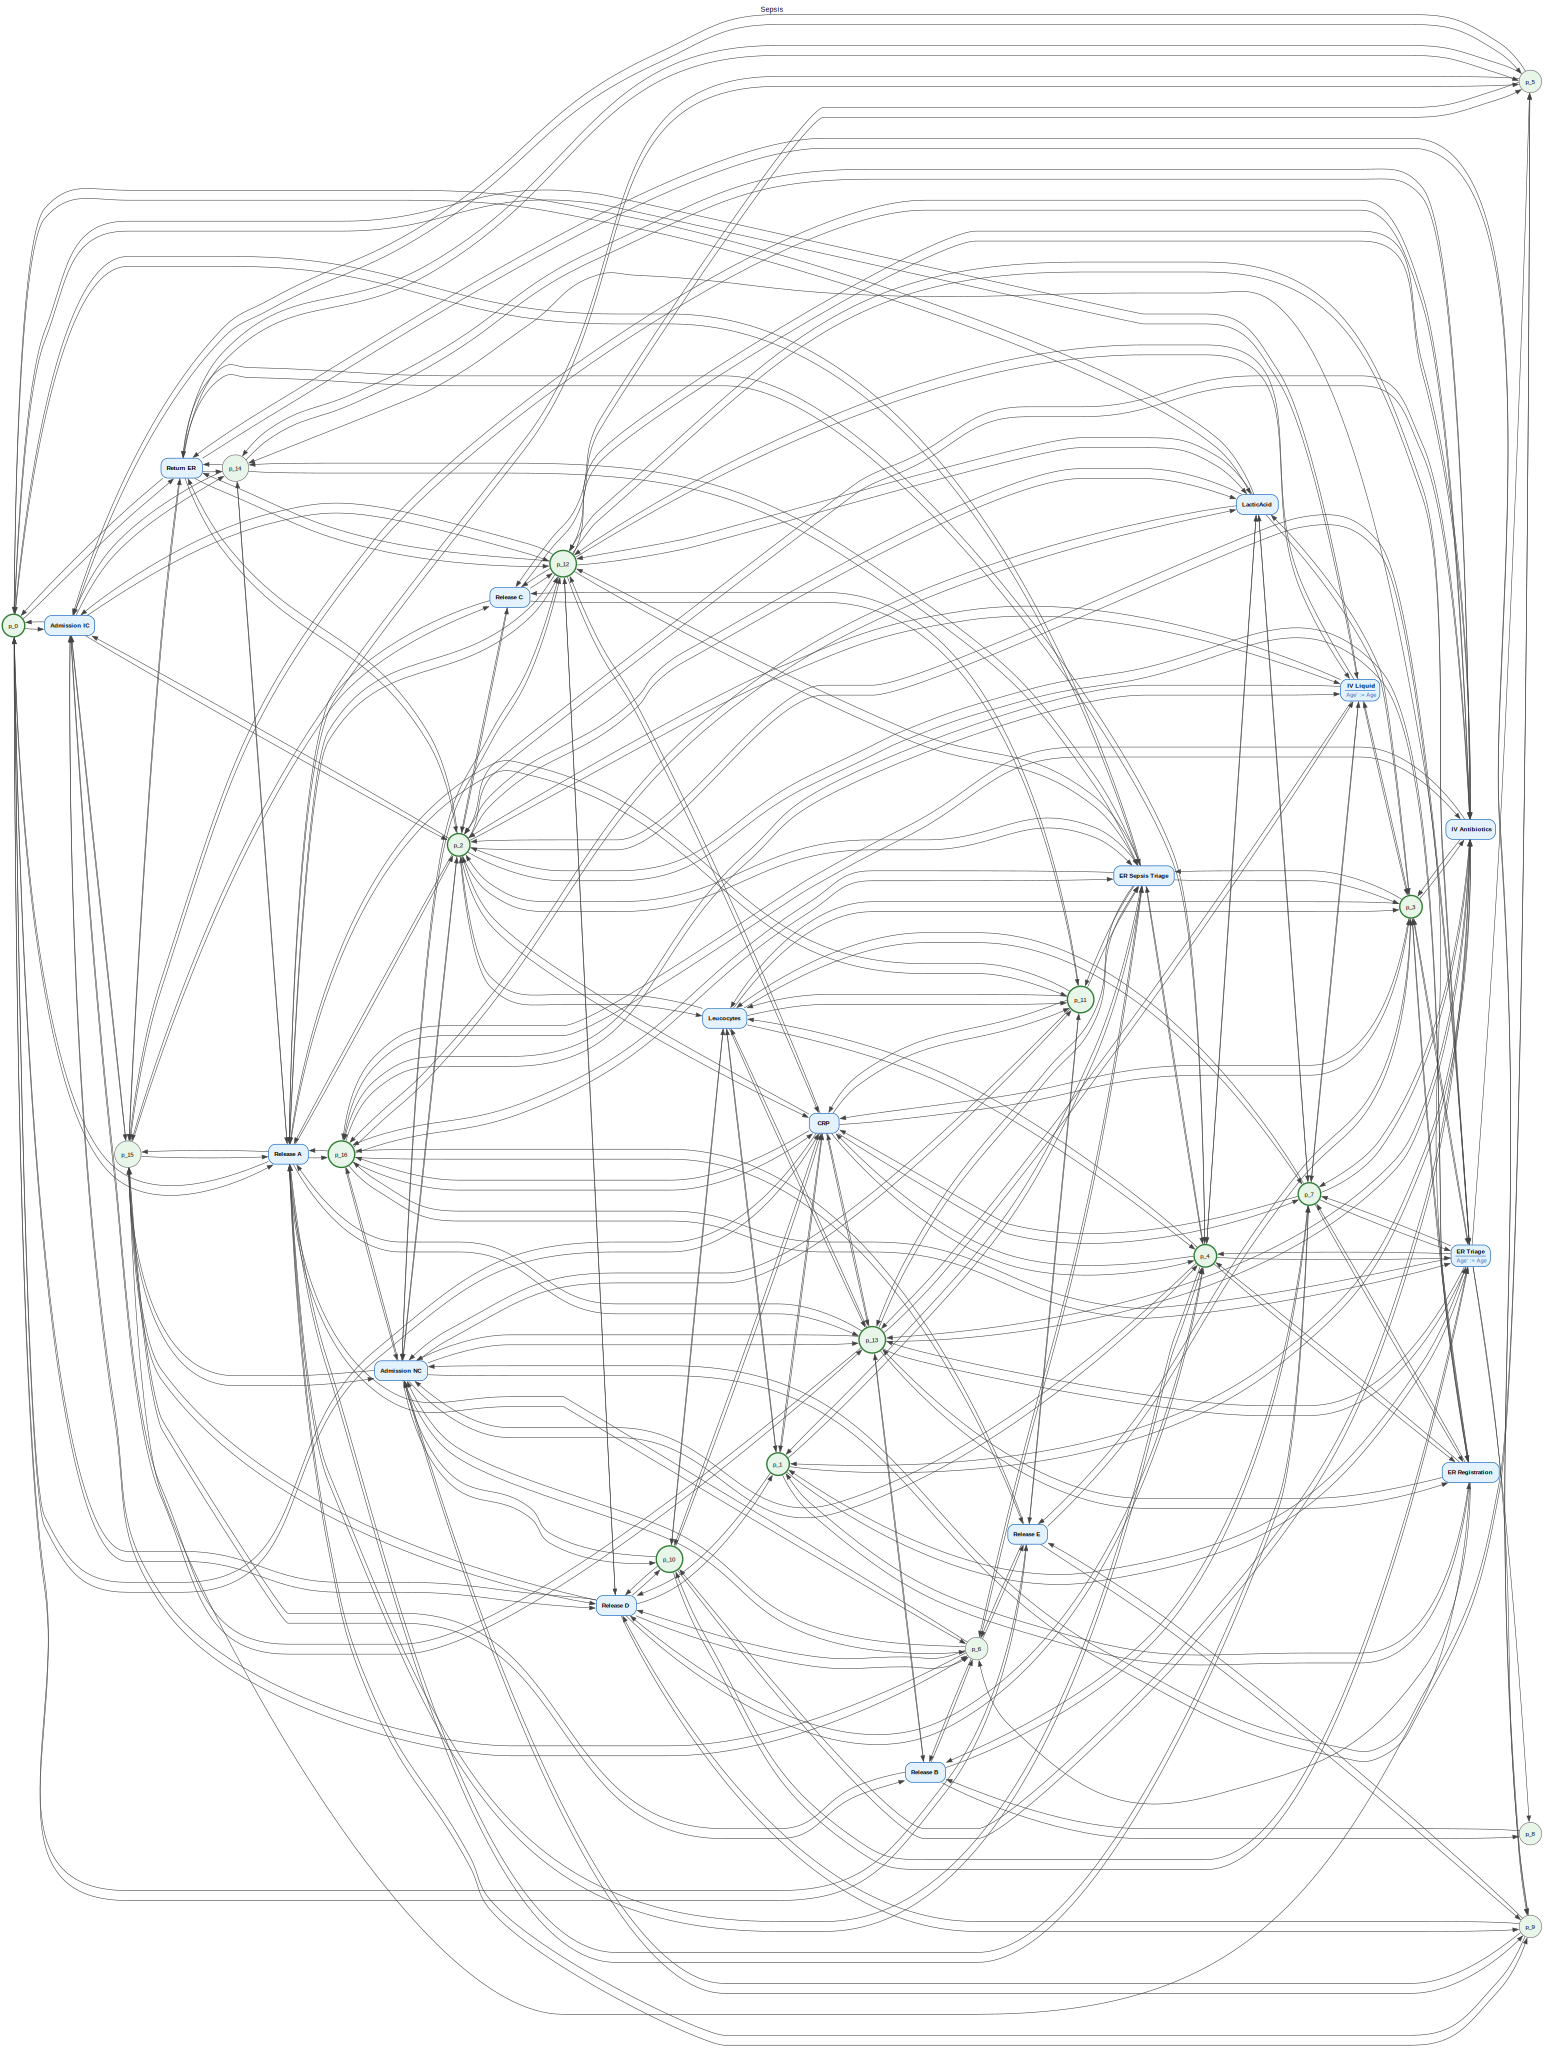

In [55]:
ilp_dpn_s = show_results_ilp("Sepsis", s_log)

INFO     Step 1  >  ILP miner: discovering control flow



  Traces: 100  |  Activities: {'DELETE', 'SET STATUS', 'MANUAL', 'ZDBC_BEHAN', 'CHANGE DIAGN', 'CODE NOK', 'CHANGE END', 'RELEASE', 'STORNO', 'BILLED', 'NEW', 'REJECT', 'JOIN-PAT', 'CODE ERROR', 'EMPTY', 'FIN', 'REOPEN', 'CODE OK'}  |  Variables: {'isCancelled', 'closeCode', 'flagA', 'speciality', 'flagB', 'blocked', 'state', 'caseType', 'msgCount', 'flagC', 'flagD', 'msgCode', 'diagnosis', 'version', 'actOrange', 'msgType', 'isClosed', 'actRed'}



discovering Petri net using ILP miner, completed causal relations ::   0%|          | 0/23 [00:00<?, ?it/s]

/Users/christianimenkamp/Documents/Git-Repositorys/Logic-Accelerated DPN Discovery/.venv/lib/python3.12/site-packages/pm4py/objects/petri_net/utils/murata.py:76: UserWarning: solution from scipy may be unstable. Please install PuLP (pip install pulp) for fully reliable results.
  warnings.warn(
INFO       ILP miner: 11 places, 13 transitions, 120 arcs
INFO     Step 2  >  Converting pm4py net to DataPetriNet
INFO              11 places, 13 transitions (before tau removal)
INFO     Step 2b >  Removing ILP-miner tau transitions
INFO       Removing sink-tau 'tau_1' and 1 sink places
INFO       Removing start-tau 'tau_2'
INFO       After tau removal: 9 places, 11 transitions
INFO     Step 3  >  Replaying log to collect data observations
INFO       Replay: 100/100 traces replayed successfully (0 failed)
INFO              11 transitions with observations, 455 total data points
INFO     Step 4  >  Grammar-based guard synthesis (A* + PHOG)
INFO       Guard synthesis: 9 choice points, 11 transit


  pm4py net : 11 places, 13 transitions
  DPN       : 9 places, 11 transitions

  ✅  All 11 activities are UNIQUE in Hospital Billing

  Discovered annotations (1 guards, 3 updates):
    t_BILLED_1                      guard = True
    t_CHANGE DIAGN_1                guard = True
    t_CODE OK_1                     guard = True
                                    actOrange' := 0
                                    msgCount' := 0
    t_DELETE_1                      guard = True
                                    isCancelled' := 1
    t_FIN_1                         guard = True
    t_JOIN-PAT_1                    guard = (and (< (* -1 isClosed) 0) (>= (+ 1/2 (* -1 flagD)) 0))
    t_NEW_1                         guard = True
                                    blocked' := 0
                                    flagA' := 0
                                    flagB' := 0
                                    isCancelled' := 0
    t_REJECT_1                      guard = True
    t_RELEASE_1 

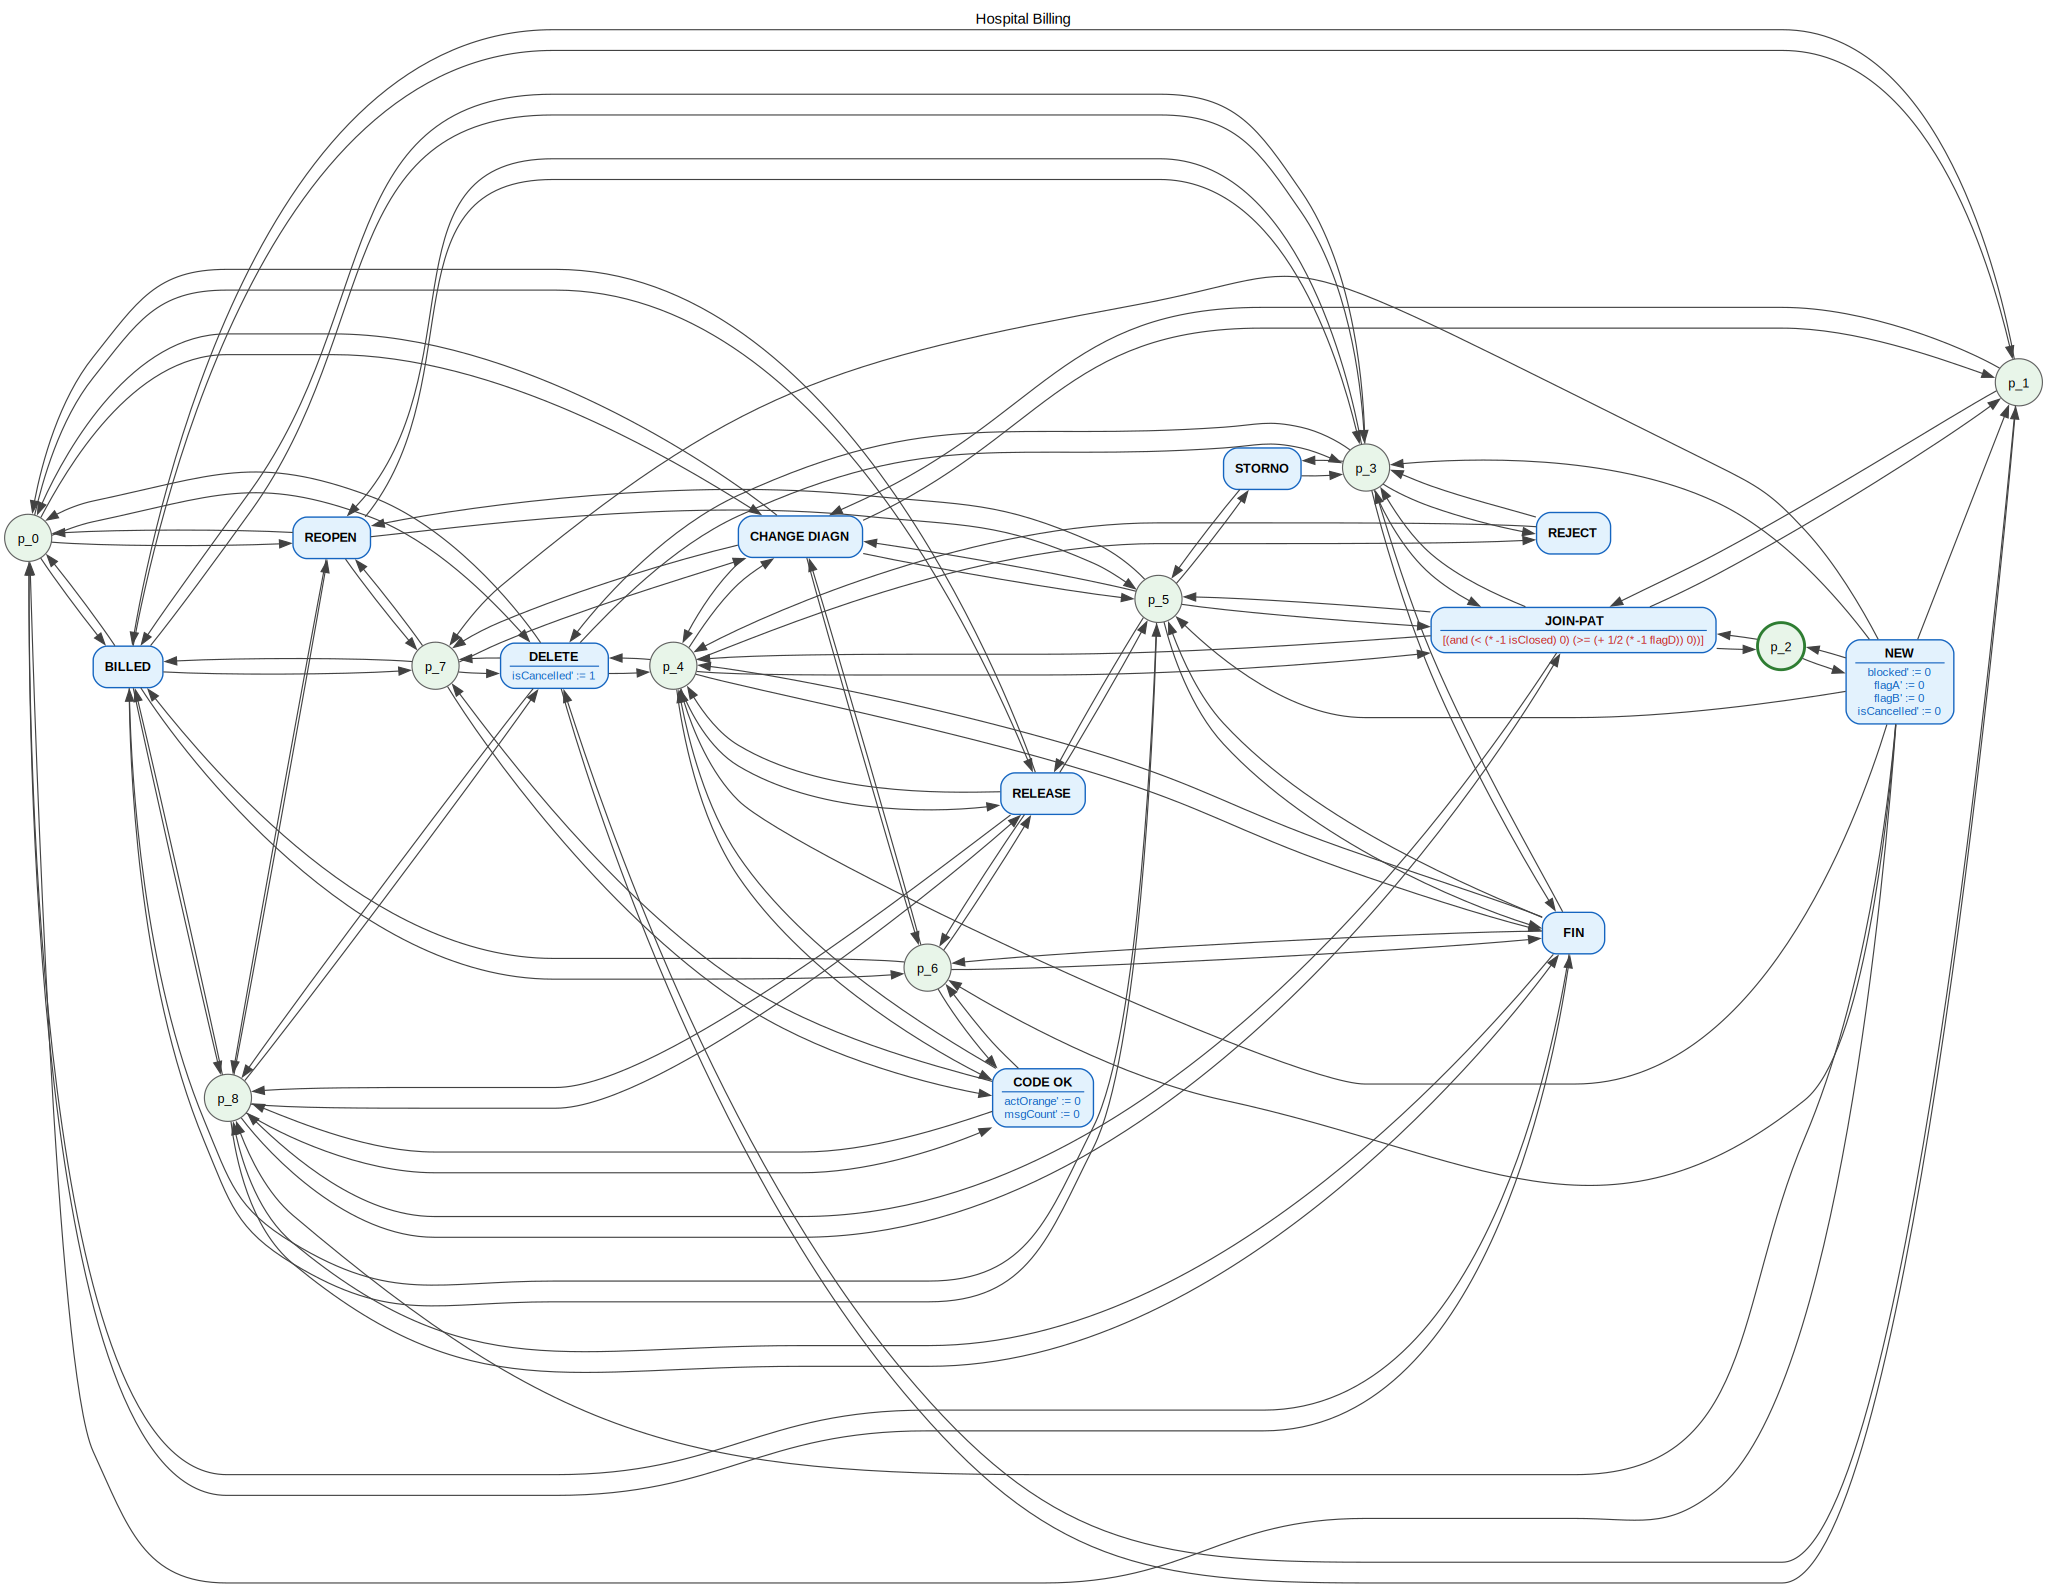

In [45]:
ilp_dpn_hb = show_results_ilp("Hospital Billing", h_log)